In [1]:
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path
from tem import plot
import pingouin as pg

root_dir = Path("~/PycharmProjects/torch_tem").expanduser()
version = "v5"
base_dir = root_dir / "tem_simulation" / "operators" / version
sim_dir = base_dir / "simulation"

# read the results of grid search
df_curves, df_peaks = plot.load_grid_results(sim_dir / "study-20")

# save
fig_dir = base_dir / "figs" / "study-20"
fig_dir.mkdir(exist_ok=True, parents=True)

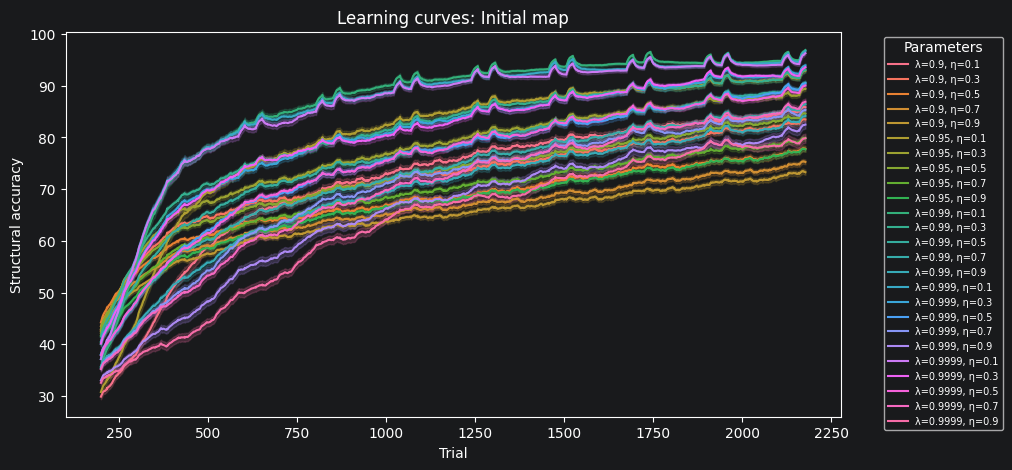

In [2]:
# learning curves for initial learning
ax = plot.plot_learning_curves(df_curves, graph="Initial")
ax.get_figure().savefig(fig_dir / "grid_learning_curves_inital.pdf", bbox_inches="tight")

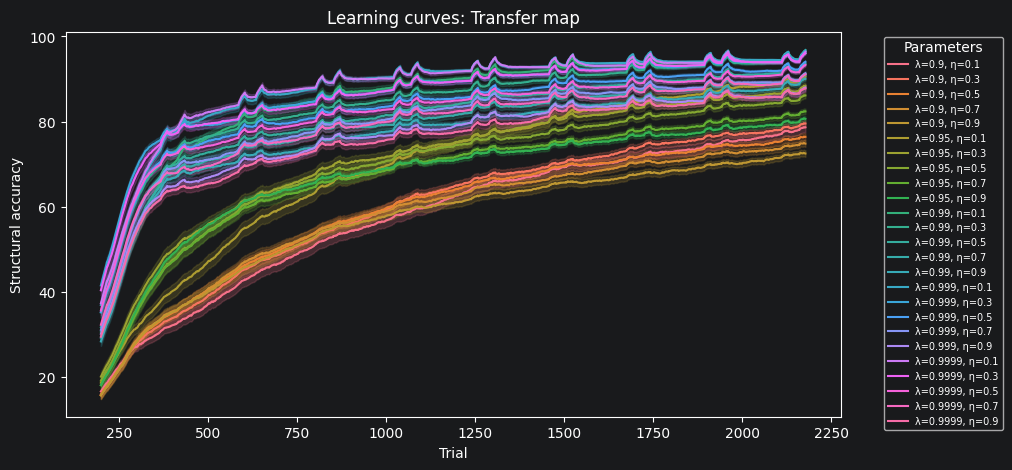

In [3]:
# learning curves for transfer learning
ax = plot.plot_learning_curves(df_curves, graph="Transfer")
ax.get_figure().savefig(fig_dir / "grid_learning_curves_transfer.pdf", bbox_inches="tight")

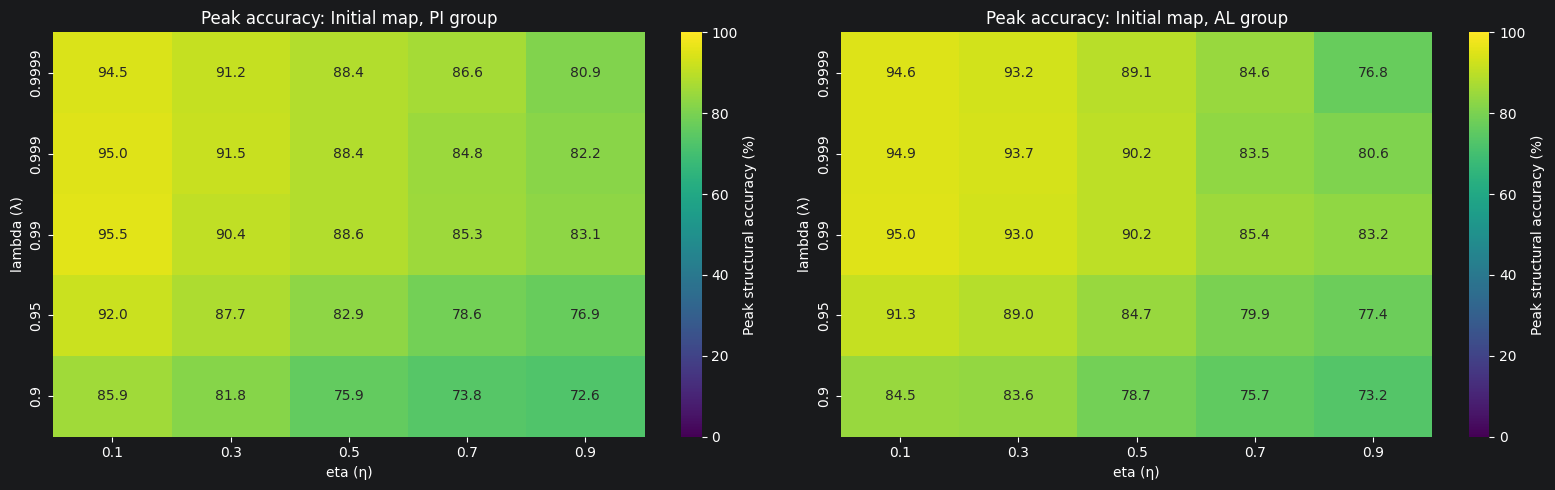

In [4]:
# heatmaps for initial learning
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot.plot_param_heatmap(df_peaks, graph="Initial", condition="PI", ax=axes[0])
plot.plot_param_heatmap(df_peaks, graph="Initial", condition="AL", ax=axes[1])
plt.tight_layout()
fig.savefig(fig_dir / "grid_heatmap_inital.pdf", bbox_inches="tight")

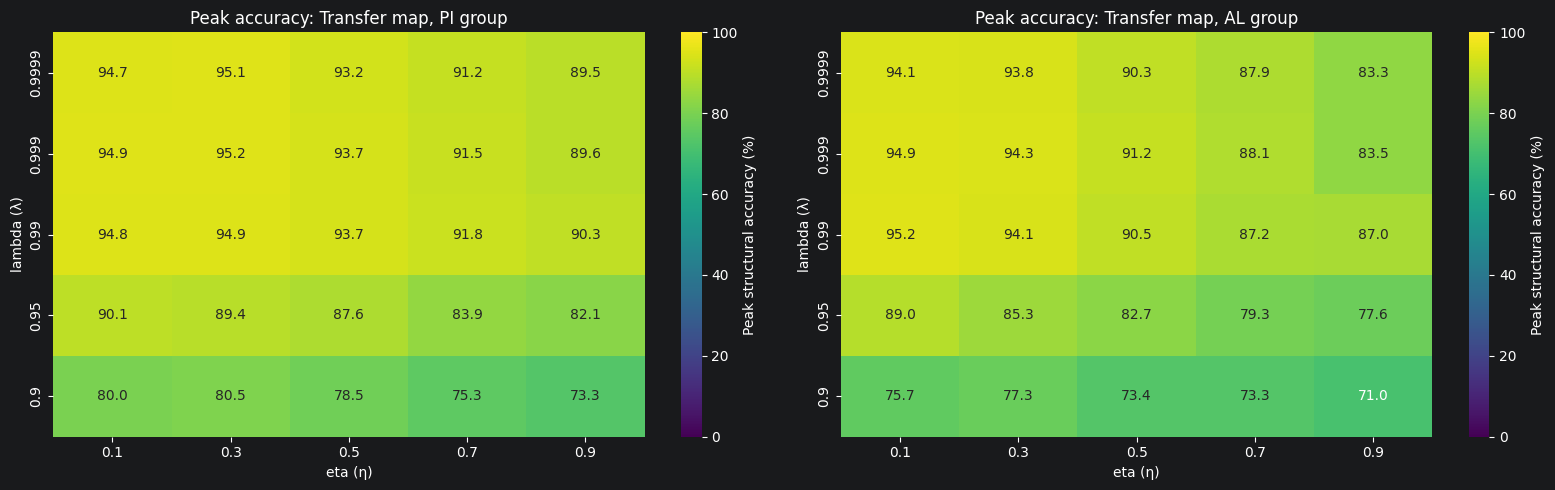

In [5]:
# heatmaps for transfer learning
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot.plot_param_heatmap(df_peaks, graph="Transfer", condition="PI", ax=axes[0])
plot.plot_param_heatmap(df_peaks, graph="Transfer", condition="AL", ax=axes[1])
plt.tight_layout()
fig.savefig(fig_dir / "grid_heatmap_transfer.pdf", bbox_inches="tight")

In [7]:
# find the curve corresponding to the optimal parameter combination
best_curves = df_curves.filter(
    (pl.col("lambda_val") == 0.999) &
    (pl.col("eta_val") == 0.3) &
    (pl.col("Graph") == "Transfer")
)

# Calculate the peak accuracy for each subject (based on the last 20% of trials).
max_trial = best_curves["Trial"].max()
trial_min = int(max_trial * 0.8)

m = (
    best_curves
    .filter(pl.col("Trial") >= trial_min)
    .group_by("subject", "condition")
    .agg(pl.col("value").mean().alias("peak_accuracy"))
    .sort("subject", "condition")
)

al = m.filter(pl.col("condition") == "AL")["peak_accuracy"].to_numpy()
pi = m.filter(pl.col("condition") == "PI")["peak_accuracy"].to_numpy()

print(f"AL n={len(al)}, PI n={len(pi)}")
print(pg.ttest(al, pi))

AL n=5, PI n=5
               T  dof alternative     p_val           CI95   cohen_d  \
T_test -1.261208    8   two-sided  0.242767  [-2.99, 0.87]  0.797658   

           power   BF10  
T_test  0.199842  0.782  
